[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Chapters/Advanced/advanced_05_svm/advanced_05_svm_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 9 — Support Vector Machines
## Lab: margins, soft margins, kernels, and tuning $C$ and $\gamma$

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).

> **Companion notebook to Advanced module A5 (ISLP Chapter 9).**
> Work through the numbered sections in order; the closing section
> *Lecture exercises — worked Python solutions* answers every exercise from the deck.
> Every number the deck quotes is reproduced here with the same seeds and the same
> methods, so you can check the slides against the code.
>
> **One warning before you start.** `SVC(C=...)` is scikit-learn's *cost per violation*:
> **large `C` means a narrow margin and *less* regularisation**. ISLP's $C$ is the opposite
> — a *budget* for violations, where large means a wide margin. Everything below uses the
> scikit-learn convention.

**Goal.** Fit hard- and soft-margin SVMs on seeded 2-D data; see what sklearn's $C$ and the radial $\gamma$ do to the boundary; take a radial SVM to the `Heart` data, scale it properly, tune $(C,\gamma)$ by cross-validation, and race it against logistic regression and a random forest on ROC AUC.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


ISLP not installed; using CSV / URL fallbacks.


## 1. Synthetic two-class data

Two concentric rings: the inner class sits *inside* the outer one, so **no straight line can separate them**. This is the data set the deck uses for every kernel comparison.

X (300, 2)  class counts [150 150]


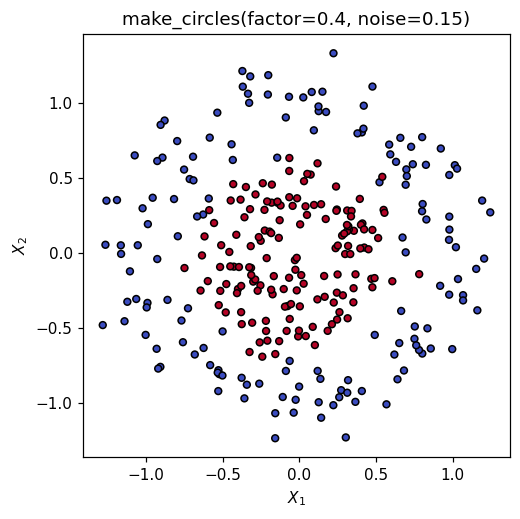

In [2]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=300, factor=0.4, noise=0.15, random_state=0)
print('X', X.shape, ' class counts', np.bincount(y))   # 150 / 150, perfectly balanced

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=20)
ax.set(xlabel='$X_1$', ylabel='$X_2$', title='make_circles(factor=0.4, noise=0.15)')
plt.show()

## 2. Linear SVM

Three things in turn: the **hard margin** on separable data (the deck's `seed 2024` picture), what sklearn's **`C`** does to a soft margin, and how badly a linear kernel fails on the rings.

In [3]:
from sklearn.svm import SVC

# The deck's separable simulation: 20 points, seed 2024, one class shifted by 2.5.
rng_geo = np.random.default_rng(2024)
Xs = rng_geo.normal(size=(20, 2))
ys = np.repeat([-1, 1], 10)
Xs[ys == 1] += 2.5

hard = SVC(kernel='linear', C=1e6).fit(Xs, ys)      # huge C ~ hard margin
w = hard.coef_[0]
print('training accuracy :', hard.score(Xs, ys))            # 1.0 -- separable
print('support vectors   :', hard.n_support_.sum(), hard.support_)
print('||beta||          :', round(float(np.linalg.norm(w)), 3))   # deck: 2.711
print('margin M = 1/||b||:', round(float(1 / np.linalg.norm(w)), 3))  # deck: 0.369
print('street width 2M   :', round(float(2 / np.linalg.norm(w)), 3))  # deck: 0.738

training accuracy : 1.0
support vectors   : 3 [ 0  4 18]
||beta||          : 2.711
margin M = 1/||b||: 0.369
street width 2M   : 0.738


**Reading the output.** The deck quotes $\|\beta\|=2.711$, $M=0.369$ and a street of width $0.738$ held open by exactly **three** support vectors — reproduced above. Deleting any of the other 17 observations would leave the fit bit-for-bit identical: they carry $\alpha_i = 0$.

In [4]:
# Overlapping data (deck seed 2025): now no hyperplane separates the classes,
# and sklearn's C decides how wide the street is.
rng_ov = np.random.default_rng(2025)
Xo = rng_ov.normal(size=(60, 2))
yo = np.repeat([-1, 1], 30)
Xo[yo == 1] += 1.6

print('hard margin feasible?  train acc =',
      round(SVC(kernel='linear', C=1e6).fit(Xo, yo).score(Xo, yo), 3))  # 0.867 -> no
print(f"{'sklearn C':>10} {'nSV':>5} {'width 2M':>9} {'sum slack':>10} {'train acc':>10}")
for C in [0.01, 0.1, 1.0, 10.0]:
    m = SVC(kernel='linear', C=C).fit(Xo, yo)
    slack = np.maximum(0.0, 1 - yo * m.decision_function(Xo)).sum()  # xi_i = max(0,1-y f)
    print(f'{C:>10g} {m.n_support_.sum():>5d} '
          f'{2 / np.linalg.norm(m.coef_):>9.2f} {slack:>10.1f} {m.score(Xo, yo):>10.3f}')

hard margin feasible?  train acc = 0.867
 sklearn C   nSV  width 2M  sum slack  train acc
      0.01    50      4.75       30.6      0.850
       0.1    31      2.15       20.8      0.867
         1    22      1.60       19.5      0.867
        10    21      1.21       19.3      0.850


**Reading the output.** Exactly the deck's table: as sklearn's `C` rises from $0.01$ to $10$ the street narrows from $4.75$ to $1.21$, the support vectors fall from $50$ to $21$, and $\sum_i\xi_i$ falls from $30.6$ to $19.3$. **Big `C`, narrow street, fewer support vectors, more variance** — the opposite of what "increase $C$ to regularise" would suggest. Note also that training accuracy is *not* monotone in $C$ ($0.850, 0.867, 0.867, 0.850$), which is why $C$ has to be chosen by cross-validation.

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Back to the rings. Even at its best CV-chosen C, a linear kernel is near-useless.
lin = make_pipeline(StandardScaler(), SVC(kernel='linear'))
lin_g = GridSearchCV(lin, {'svc__C': np.logspace(-2, 2, 9)}, cv=5).fit(X, y)
print('best C:', lin_g.best_params_, '  CV acc:', round(lin_g.best_score_, 3))  # 0.583

best C: {'svc__C': np.float64(0.01)}   CV acc: 0.583


## 3. Radial-kernel SVM

$K(x,x') = \exp(-\gamma\|x-x'\|^2)$. Small $\gamma$ = smooth and global (high bias); large $\gamma$ = an island around every support vector (high variance).

In [6]:
from sklearn.model_selection import cross_val_score

print(f"{'gamma':>8} {'CV acc':>8} {'train acc':>10} {'nSV':>5}")
for g in [0.01, 0.1, 1.0, 100.0]:
    p = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1, gamma=g))
    cv = cross_val_score(p, X, y, cv=5).mean()
    p.fit(X, y)
    print(f'{g:>8g} {cv:>8.3f} {p.score(X, y):>10.3f} {p[-1].n_support_.sum():>5d}')

   gamma   CV acc  train acc   nSV
    0.01    0.673      0.693   300
     0.1    0.960      0.960   120
       1    0.970      0.970    60
     100    0.900      1.000   285


**Reading the output.** The deck's $\gamma$ figure, in numbers. At $\gamma=0.01$ the kernel is so flat that the model cannot even see the ring (CV $0.673$). At $\gamma=100$ it classifies the **training** set perfectly ($1.000$) — and CV accuracy *drops* to $0.900$, because it has grown a private island around each point. The useful range is in between.

In [7]:
rbf = make_pipeline(StandardScaler(), SVC(kernel='rbf'))
rbf_g = GridSearchCV(rbf,
        {'svc__C': np.logspace(-2, 2, 5),
         'svc__gamma': np.logspace(-3, 1, 5)}, cv=5).fit(X, y)
print('best params:', rbf_g.best_params_,
      '  CV acc:', round(rbf_g.best_score_, 3))          # C=1, gamma=10 -> 0.98

best params: {'svc__C': np.float64(1.0), 'svc__gamma': np.float64(10.0)}   CV acc: 0.98


### Decision boundary

Side by side: the CV-tuned linear kernel against the CV-tuned radial kernel.

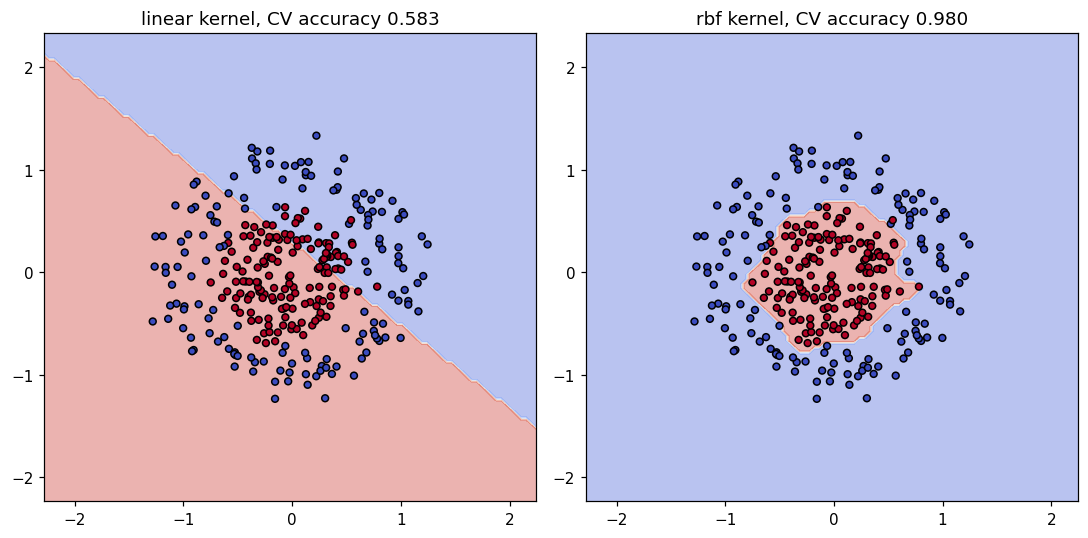

In [8]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, name, mdl, cv in [(axes[0], 'linear', lin_g.best_estimator_, lin_g.best_score_),
                          (axes[1], 'rbf',    rbf_g.best_estimator_, rbf_g.best_score_)]:
    DecisionBoundaryDisplay.from_estimator(mdl, X, ax=ax,
        response_method='predict', alpha=0.4, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=20)
    ax.set_title(f'{name} kernel, CV accuracy {cv:.3f}')
plt.tight_layout(); plt.show()

## 4. Real data: Heart

`Heart.csv` carries an unnamed row-number column (`index_col=0` keeps it out of the design matrix), six rows with missing `Ca`/`Thal`, and two categorical predictors (`ChestPain`, `Thal`) that must be encoded. The response is `AHD` (`Yes`/`No`).

In [9]:
# Heart is not in the ISLP package, so load() falls back to the CSV, whose
# first (unnamed) column is just the row number -> index_col=0 drops it.
Heart = load('Heart', index_col=0).dropna().reset_index(drop=True)
yH = (Heart['AHD'] == 'Yes').astype(int).values
XH = pd.get_dummies(Heart.drop(columns='AHD'), drop_first=True).astype(float)

from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(XH.values, yH, test_size=0.3, random_state=0)
print('after dropna:', Heart.shape, ' predictors after encoding:', XH.shape[1])
print('AHD = Yes    :', yH.sum(), f'of {len(yH)}  ({yH.mean():.3f})')
print('train / test :', len(ytr), '/', len(yte),
      ' train majority class:', round(1 - ytr.mean(), 3))

after dropna: (297, 14)  predictors after encoding: 16
AHD = Yes    : 137 of 297  (0.461)
train / test : 207 / 90  train majority class: 0.541


In [10]:
from scipy.spatial.distance import pdist

raw = SVC(kernel='rbf', C=1, gamma=0.05).fit(Xtr, ytr)             # NO scaling
sc  = make_pipeline(StandardScaler(),
                    SVC(kernel='rbf', C=1, gamma=0.05)).fit(Xtr, ytr)   # scaled
print('unscaled test acc:', round(raw.score(Xte, yte), 3),
      ' predictions [No, Yes]:', np.bincount(raw.predict(Xte)))
print('scaled   test acc:', round(sc.score(Xte, yte), 3))

d2_raw = np.median(pdist(XH.values, 'sqeuclidean'))
d2_sc  = np.median(pdist(StandardScaler().fit_transform(XH.values), 'sqeuclidean'))
print(f'median ||x-x\'||^2 : raw {d2_raw:.0f}   scaled {d2_sc:.1f}')
print(f'kernel at gamma=.05: raw {np.exp(-0.05 * d2_raw):.3g}   '
      f'scaled {np.exp(-0.05 * d2_sc):.3f}')

unscaled test acc: 0.556  predictions [No, Yes]: [86  4]
scaled   test acc: 0.822
median ||x-x'||^2 : raw 4294   scaled 31.1
kernel at gamma=.05: raw 5.83e-94   scaled 0.211


**Reading the output.** The deck quotes $0.556$ unscaled against $\mathbf{0.822}$ scaled, and that is what we get. The mechanism is in the last two lines: unscaled, `Chol` (sd $\approx 52$) dominates every distance, the median $\|x-x'\|^2$ is about $4\,294$, and $e^{-0.05\times 4294}\approx 5.8\times10^{-94}$ — the kernel matrix is numerically the identity, so $f(x)\approx\beta_0$ and the model predicts the majority class for $86$ of $90$ patients. Standardised, a typical kernel entry is $0.211$: a real similarity.

## 5. Tuning $C$ and $\gamma$ by cross-validation

Scaling goes **inside** the pipeline so that each CV fold rescales with its own training rows only. The grid is logarithmic, because $C$ and $\gamma$ act multiplicatively.

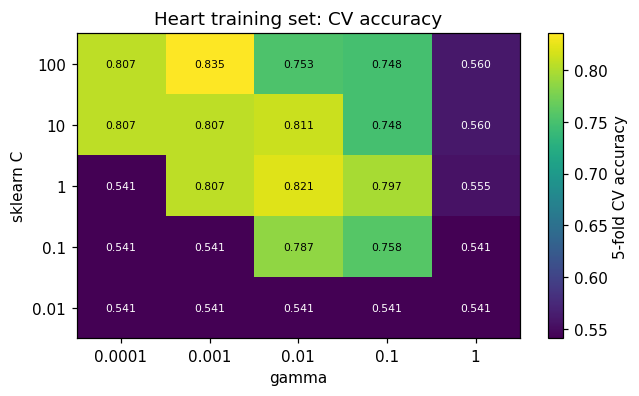

best: {'svc__C': np.float64(100.0), 'svc__gamma': np.float64(0.001)}  CV 0.835  test 0.789  nSV 80


In [11]:
Cs = np.array([0.01, 0.1, 1.0, 10.0, 100.0])
Gs = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1.0])
gs = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel='rbf')),
                  {'svc__C': Cs, 'svc__gamma': Gs}, cv=5).fit(Xtr, ytr)
S = gs.cv_results_['mean_test_score'].reshape(len(Cs), len(Gs))

fig, ax = plt.subplots(figsize=(6.5, 3.6))
im = ax.imshow(S, origin='lower', cmap='viridis', aspect='auto')
ax.set_xticks(range(len(Gs)), [f'{g:g}' for g in Gs])
ax.set_yticks(range(len(Cs)), [f'{c:g}' for c in Cs])
for i in range(len(Cs)):
    for j in range(len(Gs)):
        ax.text(j, i, f'{S[i, j]:.3f}', ha='center', va='center', fontsize=7,
                color='white' if S[i, j] < S.max() - 0.12 else 'black')
fig.colorbar(im, ax=ax, label='5-fold CV accuracy')
ax.set(xlabel='gamma', ylabel='sklearn C', title='Heart training set: CV accuracy')
plt.show()

print('best:', gs.best_params_, ' CV', round(gs.best_score_, 3),
      ' test', round(gs.score(Xte, yte), 3),
      ' nSV', gs.best_estimator_[-1].n_support_.sum())

**Reading the output.** The deck quotes the best cell as $C=100$, $\gamma=10^{-3}$ at CV accuracy $0.835$. The dark cells all sit at $0.541$ — exactly the training-set majority-class rate, i.e. models that have collapsed to "always predict No". Notice the diagonal ridge: a large $\gamma$ only survives with a small $C$, which is why the two must be tuned **jointly**.

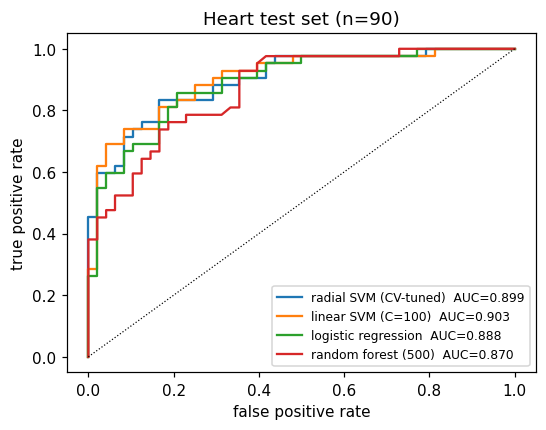

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

lin_h = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel='linear')),
                     {'svc__C': Cs}, cv=5).fit(Xtr, ytr)
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xtr, ytr)
forest = RandomForestClassifier(n_estimators=500, random_state=0).fit(Xtr, ytr)

curves = [('radial SVM (CV-tuned)', gs.best_estimator_.decision_function(Xte)),
          (f"linear SVM (C={lin_h.best_params_['svc__C']:g})",
           lin_h.best_estimator_.decision_function(Xte)),   # decision_function, NOT proba
          ('logistic regression',   logit.predict_proba(Xte)[:, 1]),
          ('random forest (500)',   forest.predict_proba(Xte)[:, 1])]

fig, ax = plt.subplots(figsize=(5.5, 4))
for lab, s in curves:
    fpr, tpr, _ = roc_curve(yte, s)
    ax.plot(fpr, tpr, label=f'{lab}  AUC={roc_auc_score(yte, s):.3f}')
ax.plot([0, 1], [0, 1], 'k:', lw=0.8)
ax.legend(loc='lower right', fontsize=8)
ax.set(xlabel='false positive rate', ylabel='true positive rate',
       title=f'Heart test set (n={len(yte)})')
plt.show()

**Reading the output.** Linear SVM $0.903$, radial SVM $0.899$, logistic regression $0.888$, random forest $0.870$ — the deck's four numbers, and a spread of only $0.033$ on $90$ test patients. The *simplest* kernel wins here, and the CV-tuned radial kernel picked $\gamma=10^{-3}$, which is so small that it is nearly linear anyway. Note that both SVMs are scored through `decision_function`: an ROC curve needs a ranking, not a probability.

## Lecture exercises — worked Python solutions

These are the **exercises from the lecture slides**, solved step by step; run them cell by cell. The `[Python]` ones are answered in code with the deck's seeds and printed numbers; the `[Concept]` and `[Math]` ones get a short written answer. Data loads through the `load()` helper defined in the Setup cell, so every cell works locally and on Colab.

### Exercise 9.1 — Reading a hyperplane [Math]

**Task (from the slides).** For $1 + 2X_1 + 3X_2 = 0$: classify $(0,0)$, $(-1,1)$, $(2,-2)$; give $\|\beta\|$ and each point's distance; then multiply all coefficients by $10$.

**Answer.** $\|\beta\| = \sqrt{2^2+3^2} = \sqrt{13} = 3.6056$.

| $x$ | $f(x)=1+2x_1+3x_2$ | $\hat y$ | $\lvert f\rvert/\lVert\beta\rVert$ |
|---|---|---|---|
| $(0,0)$ | $+1$ | $+1$ | $0.277$ |
| $(-1,1)$ | $+2$ | $+1$ | $0.555$ |
| $(2,-2)$ | $-1$ | $-1$ | $0.277$ |

Multiplying the coefficients by $10$ multiplies every score by $10$ **and** $\|\beta\|$ by $10$. Every sign — hence every prediction — is unchanged, and so is every distance $|f|/\|\beta\|$. **The sign and the distance are invariant; the raw score is not.** That arbitrary scale is exactly what the canonical constraint $y_i f(x_i)\ge 1$ pins down.

### Exercise 9.2 — The maximal margin by hand [Math]

**Task (from the slides).** Seven points, $y=-1$ at $(3,4),(2,2),(4,4),(1,4)$ and $y=+1$ at $(2,1),(4,3),(4,1)$. Find the optimal line, its canonical form, the margin, and the support vectors.

**Answer.** Along $X_1-X_2$ the $-1$ class gives $\{-1,0,0,-3\}$ and the $+1$ class gives $\{1,1,3\}$; the extremes are $0$ and $1$, so the widest street puts the boundary at the midpoint, $X_2 = X_1 - \tfrac12$. Rescaling so the nearest points score $\pm1$:

$$f(x) = -1 + 2x_1 - 2x_2,\qquad \beta_0=-1,\quad \beta = (2,-2)^\top,\quad \|\beta\| = 2\sqrt2 = 2.8284,$$

so $M = 1/\|\beta\| = 0.3536$ and the street width is $2M = 1/\sqrt2 = 0.7071$. The four points on the margin — $(2,2)$, $(4,4)$, $(2,1)$, $(4,3)$ — are the support vectors. Moving observation 7 from $(4,1)$ to $(4.5,0.5)$ takes it *further* away ($f$ goes from $+5$ to $+7$), so nothing about the fit changes. The cell below checks all of this.

In [13]:
P = np.array([[3, 4], [2, 2], [4, 4], [1, 4], [2, 1], [4, 3], [4, 1]], float)
lab = np.array([-1, -1, -1, -1, 1, 1, 1])
m = SVC(kernel='linear', C=1e6).fit(P, lab)

print('beta   :', np.round(m.coef_[0], 3), '  beta_0:', round(float(m.intercept_[0]), 3))
print('||beta||:', round(float(np.linalg.norm(m.coef_)), 4),
      '  M:', round(float(1 / np.linalg.norm(m.coef_)), 4))
print('y*f(x) :', np.round(lab * m.decision_function(P), 3))   # ==1 at the four SVs
print('sklearn support_ (0-based):', m.support_)

beta   : [ 2. -2.]   beta_0: -1.0
||beta||: 2.8281   M: 0.3536
y*f(x) : [3.    1.    1.    6.999 1.    1.    4.999]
sklearn support_ (0-based): [1 2 5]


**Reading the output.** `SVC` recovers $\beta=(2,-2)$, $\beta_0=-1$, $M=0.3536$, and `y*f(x)` equals $1$ at observations 2, 3, 5 and 6 (1-based). Note that `support_` lists only **three** of the four: with four points tied on the margin the dual solution is not unique, so one multiplier can come out exactly zero. Geometrically all four are support vectors.

### Exercise 9.3 — Slacks, budgets and sklearn's $C$ [Concept]

**Answer.**

1. The **margin** $M$ is maximised, subject to $y_i f(x_i) \ge M(1-\xi_i)$ and $\xi_i \ge 0$. The budget sits on the **sum** of the slacks, $\sum_{i=1}^n \xi_i \le C_{\text{ISLP}}$ — not on each $\xi_i$, and not on a *count* of violations.
2. $\xi_i = 0.4 \in (0,1]$: inside the street, still on the correct side. $\xi_i = 1.8 > 1$: on the wrong side, misclassified. Both satisfy $y_i f(x_i)\le 1$, so **both are support vectors**.
3. The direction is inverted. sklearn minimises $\tfrac12\|\beta\|^2 + C\sum_i\xi_i$, i.e. penalty weight $\lambda = 1/(2C)$. Raising $C$ from $0.1$ to $100$ **weakens** regularisation: the slacks shrink, $\|\beta\|$ grows, the margin $1/\|\beta\|$ *narrows*, and $|\mathcal S|$ *falls*. Section 2 above shows exactly this on 60 simulated points.
4. $196$ of $200$ points have $y_i f(x_i)\le 1$, so almost the whole sample lies inside a very wide street: a **small** $C$, a heavily regularised, high-bias, low-variance fit. Many support vectors is a smoothness signal, **not** an overfitting signal.

### Exercise 9.4 — The polynomial kernel is an inner product [Math]

**Answer.** With $s = x_1x_1' + x_2x_2'$,

$$K = (1+s)^2 = 1 + 2x_1x_1' + 2x_2x_2' + x_1^2x_1'^2 + x_2^2x_2'^2 + 2x_1x_2x_1'x_2',$$

which is $\langle\phi(x),\phi(x')\rangle$ for

$$\phi(x) = \bigl(1,\ \sqrt2\,x_1,\ \sqrt2\,x_2,\ x_1^2,\ x_2^2,\ \sqrt2\,x_1x_2\bigr) \in \mathbb{R}^6,\qquad m = 6 = \binom{4}{2}.$$

Dropping the $\sqrt2$ factors gives a *different* kernel. Cost: three multiplications through $K$, six (plus building and storing both vectors) through $\phi$. For $p=100$, $d=3$ the enlarged space has $\binom{103}{3} = 176\,851$ dimensions, against $p+1 = 101$ multiplications per kernel entry — the same fit at a cost that never depends on the enlarged dimension.

### Exercise 9.5 — Kernels on the concentric data [Python]

**Task (from the slides).** On `make_circles(n_samples=300, factor=0.4, noise=0.15, random_state=0)`, tune a linear SVM over `C = np.logspace(-2, 2, 9)`, a radial SVM over `C = np.logspace(-2, 2, 5)` and `gamma = np.logspace(-3, 1, 5)`, and fit a degree-2 polynomial kernel with `coef0=1, C=1`. Explain the gap.

In [14]:
pipe = lambda **kw: make_pipeline(StandardScaler(), SVC(**kw))    # scale, then fit

lin5 = GridSearchCV(pipe(kernel='linear'),                        # (1) linear
                    {'svc__C': np.logspace(-2, 2, 9)}, cv=5).fit(X, y)
rbf5 = GridSearchCV(pipe(kernel='rbf'),                           # (2) radial
                    {'svc__C': np.logspace(-2, 2, 5),
                     'svc__gamma': np.logspace(-3, 1, 5)}, cv=5).fit(X, y)
pol5 = cross_val_score(pipe(kernel='poly', degree=2, coef0=1, C=1), X, y, cv=5)

print('linear', lin5.best_params_, round(lin5.best_score_, 3))    # 0.583
print('radial', rbf5.best_params_, round(rbf5.best_score_, 3))    # 0.98
print('poly d=2  CV', round(pol5.mean(), 3))                      # 0.963

linear {'svc__C': np.float64(0.01)} 0.583
radial {'svc__C': np.float64(1.0), 'svc__gamma': np.float64(10.0)} 0.98
poly d=2  CV 0.963


**Reading the output.** The deck's three numbers: linear $0.583$, radial $\mathbf{0.980}$, polynomial degree 2 $0.963$. With a 50/50 split, $0.583$ is barely above a coin flip — and CV picked the *smallest* $C$, because when no line can work the wide margin at least keeps the fit stable. Degree 2 nearly matches the radial kernel, which is no accident: the true boundary is a circle, exactly a degree-2 surface. The failure of the linear kernel is about the boundary's **shape**, so no value of $C$ can repair it; only a change of kernel can.

One trap worth repeating: `coef0=1` is essential. scikit-learn's polynomial kernel is $(\gamma\langle x,x'\rangle + r)^d$ with $r =$ `coef0` $= 0$ by default, which drops all the lower-order terms and is *not* ISLP's $(1+\langle x,x'\rangle)^d$.

### Exercise 9.6 — Scaling the Heart predictors [Python]

**Task (from the slides).** Fit `SVC(kernel='rbf', C=1, gamma=0.05)` on the raw Heart predictors and again inside a `StandardScaler` pipeline; then compute the median squared distance between patients, raw and standardised, and explain the difference.

In [15]:
# (a) unscaled ---------------------------------------------------------------
raw6 = SVC(kernel='rbf', C=1, gamma=0.05).fit(Xtr, ytr)
print('unscaled test acc:', round(raw6.score(Xte, yte), 3),
      ' predicted [No, Yes]:', np.bincount(raw6.predict(Xte)),
      f' (test set is {yte.mean():.3f} Yes)')

# (b) scaled -----------------------------------------------------------------
sc6 = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1, gamma=0.05)).fit(Xtr, ytr)
print('scaled   test acc:', round(sc6.score(Xte, yte), 3))

# (c) why: the spread of the predictors, and what it does to the kernel -------
print('\nlargest / smallest predictor sd:',
      round(XH.std().max(), 2), '(', XH.std().idxmax(), ') vs',
      round(XH.std().min(), 2), '(', XH.std().idxmin(), ')')
print('median d^2 : raw %.0f   scaled %.1f' % (d2_raw, d2_sc))
print('exp(-0.05 * median d^2): raw %.3g   scaled %.3f'
      % (np.exp(-0.05 * d2_raw), np.exp(-0.05 * d2_sc)))

unscaled test acc: 0.556  predicted [No, Yes]: [86  4]  (test set is 0.467 Yes)
scaled   test acc: 0.822

largest / smallest predictor sd: 52.0 ( Chol ) vs 0.27 ( ChestPain_typical )
median d^2 : raw 4294   scaled 31.1
exp(-0.05 * median d^2): raw 5.83e-94   scaled 0.211


**Reading the output.** $0.556$ against $\mathbf{0.822}$ — a 27-point gain from three words of code, exactly as the deck quotes. Unscaled, the model predicts "Yes" for only 4 of 90 patients while the test set is $46.7\%$ "Yes": it has collapsed to the majority-class rule. The reason is in part (c): `Chol` has standard deviation $52.0$ while the smallest spread in the design matrix is a dummy at $0.27$ (and the binary `Fbs` sits at $0.35$), so the median squared distance between two patients is about $4\,294$ raw and $e^{-0.05\times4294}=5.8\times10^{-94}$ — every off-diagonal kernel entry underflows, the kernel matrix is numerically the identity, and $f(x)\approx\beta_0$. Standardised, the median distance is $31.1$ and a typical kernel entry is $0.211$.

$\gamma$ is measured in inverse *squared units of the predictors*. An SVM without a scaler is not a model.

### Exercise 9.7 — Counting multi-class classifiers [Concept]

**Answer.**

1. OVO needs $\binom{K}{2} = K(K-1)/2$: **6** for $K=4$ and **45** for $K=10$. OVA needs $K$: **4** and **10**.
2. With $K=10$ balanced classes and $n=10\,000$, each class has $1\,000$ observations, so an OVO fit sees $2\,000$ rows and an OVA fit sees all $10\,000$.
3. With training cost $\propto m^2$: OVO costs $45 \times 2\,000^2 = 1.8\times10^{8}$ and OVA costs $10 \times 10\,000^2 = 1.0\times10^{9}$. OVO does about $5.6\times$ **less** work despite fitting $4.5\times$ as many models — which is why `SVC` defaults to it.
4. OVA gives exactly one score $f_k(x)$ per class, so prediction is a single $\arg\max$ with no ties and no vote counting, and each fit answers a question we care about ("is it class $k$?"). Its weakness mirrors OVO's: each fit is badly unbalanced (1 against 9), and the $K$ scores are not on a comparable scale.

### Extended Exercise 9.1 — From hard to soft margin by hand [Math]

**Answer.** Adding $(2,3)$ with $y_8=+1$ puts a $+1$ point at $x_1-x_2=-1$, the same coordinate as the $-1$ point $(3,4)$: the two classes' convex hulls now intersect, so **no** hyperplane separates them and the hard-margin programme is infeasible.

Keeping $f(x)=-1+2x_1-2x_2$ and computing $\xi_i = \max\{0,\,1-y_i f(x_i)\}$:

| $i$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|---|---|---|---|---|---|---|---|---|
| $y_i f(x_i)$ | 3 | 1 | 1 | 7 | 1 | 1 | 5 | $-3$ |
| $\xi_i$ | 0 | 0 | 0 | 0 | 0 | 0 | 0 | **4** |

so $\sum_i \xi_i = 4$: **one badly placed observation consumes the entire budget**, which is the honest reading of "the budget is on the *sum* of the slacks". This $f$ is feasible as soon as $C_{\text{ISLP}} \ge 4$, and the support vectors are now observations 2, 3, 5, 6 (on the kerb) and 8 (misclassified) — five in all.

In sklearn's objective the fit costs $\tfrac12(2\sqrt2)^2 + 4C = 4 + 4C$. With a **small** $C$ the slack term is cheap, so the solver buys more slack for a smaller $\|\beta\|$: it tilts and *widens* the street and becomes far less sensitive to point 8. With a **large** $C$ it contorts to keep $\xi_8$ small, ending with a large $\|\beta\|$ and a narrow, unstable margin. (A common slip: $\xi_8$ lives on the *functional* margin scale, so it is $4$, not $4/\|\beta\| = 1.41$.)

### Extended Exercise 9.2 — Tune an SVM on Heart and race it [Python]

**Task (from the slides).** On the Heart split (207 train / 90 test): tune a radial SVM over $C \in \{10^{-2},\dots,10^{2}\}$ and $\gamma \in \{10^{-4},\dots,10^{0}\}$ and a linear SVM over the same $C$ grid; fit a scaled logistic regression and a 500-tree random forest; report the test ROC AUC of all four.

In [16]:
for nm, g in [('radial', gs), ('linear', lin_h)]:                 # (1) and (2)
    print(nm, g.best_params_, 'CV', round(g.best_score_, 3),
          'test', round(g.score(Xte, yte), 3),
          'nSV', g.best_estimator_[-1].n_support_.sum())

scores = {                                    # (3) and (4): four contenders
    'radial SVM': gs.best_estimator_.decision_function(Xte),      # NOT predict_proba
    'linear SVM': lin_h.best_estimator_.decision_function(Xte),
    'logistic':   logit.predict_proba(Xte)[:, 1],
    'forest':     forest.predict_proba(Xte)[:, 1],
}
for nm, s in scores.items():
    print('%-11s AUC=%.3f' % (nm, roc_auc_score(yte, s)))
aucs = [roc_auc_score(yte, s) for s in scores.values()]
print('spread of the four AUCs: %.3f' % (max(aucs) - min(aucs)))

radial {'svc__C': np.float64(100.0), 'svc__gamma': np.float64(0.001)} CV 0.835 test 0.789 nSV 80
linear {'svc__C': np.float64(100.0)} CV 0.84 test 0.822 nSV 72
radial SVM  AUC=0.899
linear SVM  AUC=0.903
logistic    AUC=0.888
forest      AUC=0.870
spread of the four AUCs: 0.033


**Reading the output.** The deck's numbers: radial SVM CV $0.835$ / test $0.789$ / 80 support vectors at $C=100,\ \gamma=10^{-3}$; linear SVM CV $0.840$ / test $0.822$ / 72 support vectors at $C=100$. Test AUCs are $0.899$, $0.903$, $0.888$, $0.870$ — a spread of $0.033$ across four quite different methods on 90 patients, comfortably inside sampling noise at this sample size.

Two conclusions. First, cross-validation itself told us the radial kernel is not wanted: it selected $\gamma = 10^{-3}$, small enough that $\exp(-\gamma\|x-x'\|^2)\approx 1-\gamma\|x-x'\|^2$ and the kernel is effectively linear. Second, the **linear** SVM is at least as good on both CV accuracy and test AUC, with fewer support vectors and one hyperparameter instead of two — so prefer it. Do not read a $0.033$ AUC gap on $n=90$ as a real ranking; bootstrap a confidence interval first.

In [17]:
# A caveat worth seeing once: probability=True refits a Platt calibration with an
# internal 5-fold CV. It is a different estimator -- use decision_function for ROC.
from scipy.stats import spearmanr

plat = make_pipeline(StandardScaler(),
                     SVC(kernel='rbf', C=100, gamma=0.001,
                         probability=True, random_state=0)).fit(Xtr, ytr)
pp = plat.predict_proba(Xte)[:, 1]
df = gs.best_estimator_.decision_function(Xte)
print('AUC from predict_proba   :', round(roc_auc_score(yte, pp), 3))
print('AUC from decision_function:', round(roc_auc_score(yte, df), 3))
print('Spearman rank correlation :', round(float(spearmanr(df, pp).statistic), 3))

AUC from predict_proba   : 0.899
AUC from decision_function: 0.899
Spearman rank correlation : 1.0


**Reading the output.** Here Platt scaling happens to preserve the ranking exactly (Spearman $1.00$, identical AUC $0.899$), which is the deck's claim. That is *not* a guarantee: `probability=True` fits a separate logistic calibration by internal cross-validation, so it is a different, seeded, slower estimator whose probabilities need not agree with $\operatorname{sign} f(x)$. For ROC and AUC, use `decision_function`; reach for `probability=True` only when you genuinely need a probability.

### Extended Exercise 9.3 — Choosing a classifier [Integrative]

**Answer (appendix exercise; no code needed).**

- **A — proteomics assay, $n=90$, $p=3\,000$.** An SVM, and start **linear**. With $p/n = 33$ the data are certainly separable, so unpenalised logistic regression will not converge and a forest has little to split on with 90 rows. The margin is well defined even here, and the kernel matrix is only $90\times90$. *What would change my mind:* a per-patient probability requirement — then penalised logistic regression.
- **B — consumer credit, $n=400\,000$, mixed predictors, regulated.** Penalised logistic regression, or a boosted tree with SHAP. Three deal-breakers for the SVM: an $n\times n$ kernel matrix would need $1.6\times10^{11}$ entries; the decision needs a calibrated $\Pr(\text{default})$; and adverse-action notices need per-applicant reason codes. Missing income and categorical predictors point the same way.
- **C — factory novelty detection, mostly normal traces, threshold set later.** A **one-class** SVM. The negative class is barely observed, so fit the *support* of the normal class instead of a two-class boundary; all 60 features are continuous; and because operations sets the alarm threshold later, a monotone score from `decision_function` is exactly the right deliverable. *What would change my mind:* enough labelled faults to train a supervised boosted model.

**The common thread.** The SVM wins where $p/n$ is hostile, where the deliverable is a *score* rather than a probability, and where a bespoke similarity is natural. It loses where $n$ is huge, where probabilities are contractual, and where a human must be told why.

## 6. Exercises

1. Re-run Section 2's $C$ sweep with the classes shifted by `1.0` instead of `1.6`. How do the support-vector counts and $\sum_i\xi_i$ change, and why?
2. Extend the Heart grid in Section 5 to $\gamma \in \{10^{-5},\dots,10^{1}\}$. Does the winning cell move to the edge of the grid? What would that tell you?
3. Try a polynomial kernel of degree 3 on `make_circles`, with and without `coef0=1`. Explain the difference.
4. Bootstrap the Heart test set 1000 times and report a 95% interval for the gap in AUC between the linear SVM and the random forest. Is the ranking in Section 5 real?